# Defactify / MS-COCOAI — Initial Data Exploration
**Team Vera · MLOps (UPC, 2026-27 Q1) · Milestone 1**

Dataset discovery for our *real vs. AI-generated image* detector.

- **Source:** [`Rajarshi-Roy-research/Defactify_Image_Dataset`](https://huggingface.co/datasets/Rajarshi-Roy-research/Defactify_Image_Dataset) — paper [arXiv 2601.00553](https://arxiv.org/abs/2601.00553)
- **Task:** binary `real` vs `AI-generated` (Task A); bonus generator attribution (Task B).
- **Reals:** MS COCO. **Fakes:** 5 modern generators (SD 2.1, SDXL, SD 3, DALL·E 3, MidJourney v6, 2022-24).
- **License:** CC BY 4.0 (author-declared in the paper) — attribute the paper **and** MS COCO.

**What this notebook answers**
1. Schema, splits, label semantics
2. Class balance (real/fake imbalance) + per-generator counts
3. Image properties + **shortcut audit** (aspect-ratio / format leakage)
4. Caption analysis & same-caption pairing (content-bias control)
5. Train/val/test leakage sanity check
6. Implications for preprocessing, modelling & the dataset card

> **Loading strategy.** We read only the **label/caption columns** across all shards (fast, a few MB) for the distribution work, and pull one **small image batch** for pixel-level checks — so this runs on a laptop **without downloading the full 7.5 GB**.

In [1]:
import io, re, time, collections
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import pyarrow.parquet as pq
from huggingface_hub import HfApi, HfFileSystem

REPO_ID = "Rajarshi-Roy-research/Defactify_Image_Dataset"
CACHE   = Path("../data/interim/defactify_metadata.parquet")

# Label semantics (verified from the data):
#   Label_A: 0 = real, 1 = AI-generated   (binary  -> Task A)
#   Label_B: 0 = real, 1..5 = generator   (attribution -> Task B)
# The five generators are SD 2.1, SDXL, SD 3, DALL-E 3, MidJourney v6.
# WARNING: confirm the exact integer->generator order against the dataset card
#          before quoting names in the final dataset card. We report by integer.
LABEL_A = {0: "real", 1: "AI-generated"}
GEN     = {0: "real (COCO)", 1: "gen_1", 2: "gen_2", 3: "gen_3", 4: "gen_4", 5: "gen_5"}

pd.set_option("display.max_columns", 30)
plt.rcParams["figure.dpi"] = 110
fs = HfFileSystem()
print("dataset:", REPO_ID)

dataset: Rajarshi-Roy-research/Defactify_Image_Dataset


## 1 · Schema, shards & splits
The dataset ships as sharded parquet under `data/`. Each row = one image + its caption + two labels.

In [2]:
api = HfApi()
tree = api.list_repo_tree(REPO_ID, repo_type="dataset", path_in_repo="data", recursive=True)
shards = sorted(t.path for t in tree if t.path.endswith(".parquet"))
split_of = lambda p: re.match(r"data/(\w+)-", p).group(1)
by_split = collections.defaultdict(list)
for s in shards:
    by_split[split_of(s)].append(s)
print("shards per split:", {k: len(v) for k, v in by_split.items()}, "| total shards:", len(shards))
print("columns:", ["Caption (str)", "Image (bytes)", "Label_A (int)", "Label_B (int)"])

shards per split: {'test': 8, 'train': 7, 'validation': 2} | total shards: 17
columns: ['Caption (str)', 'Image (bytes)', 'Label_A (int)', 'Label_B (int)']


## 2 · Class balance
We read only `Label_A`, `Label_B`, `Caption` across every shard (column projection skips the heavy image bytes), then cache the result.

In [3]:
def read_meta():
    frames = []
    for sp, paths in by_split.items():
        for p in paths:
            df = pd.read_parquet(f"hf://datasets/{REPO_ID}/{p}",
                                 columns=["Label_A", "Label_B", "Caption"])
            df["split"] = sp
            frames.append(df)
    return pd.concat(frames, ignore_index=True)

if CACHE.exists():
    meta = pd.read_parquet(CACHE); print("loaded cached metadata:", len(meta), "rows")
else:
    t = time.time(); meta = read_meta()
    CACHE.parent.mkdir(parents=True, exist_ok=True); meta.to_parquet(CACHE)
    print(f"read metadata for {len(meta):,} rows in {time.time()-t:.0f}s  (cached -> {CACHE})")
meta.head()

loaded cached metadata: 96000 rows


,Label_A,Label_B,Caption,split
0,1,5,School buses parked along the curb of a city s...,test
1,0,0,A distant airplane high up into the sky.,test
2,1,1,A herd of cattle laying in the grass on the gr...,test
3,0,0,A dog on a leash in front of a closed door,test
4,1,5,The large winged bird is looking for some prey.,test


In [4]:
print("Total images:", f"{len(meta):,}")
meta.groupby("split").size().rename("n_images").to_frame()

Total images: 96,000


,n_images
split,
test,45000
train,42000
validation,9000


{'AI-generated': 80000, 'real': 16000} |  fake:real = 5.0 : 1


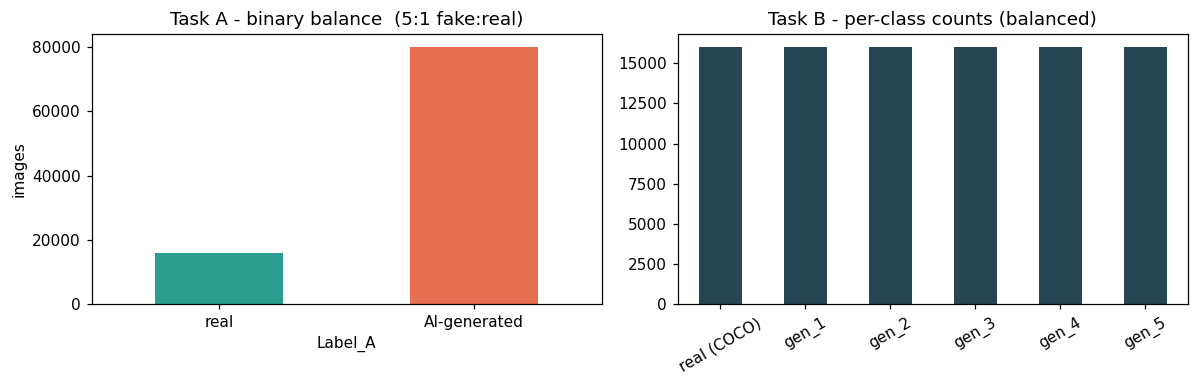

In [5]:
counts_A = meta["Label_A"].map(LABEL_A).value_counts()
ratio = counts_A["AI-generated"] / counts_A["real"]
print(counts_A.to_dict(), f"|  fake:real = {ratio:.1f} : 1")

gb = meta["Label_B"].value_counts().sort_index()
gb.index = [GEN[i] for i in gb.index]

fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
counts_A.reindex(["real", "AI-generated"]).plot.bar(ax=ax[0], color=["#2a9d8f", "#e76f51"])
ax[0].set_title(f"Task A - binary balance  ({ratio:.0f}:1 fake:real)"); ax[0].set_ylabel("images")
ax[0].tick_params(axis="x", rotation=0)
gb.plot.bar(ax=ax[1], color="#264653")
ax[1].set_title("Task B - per-class counts (balanced)"); ax[1].tick_params(axis="x", rotation=30)
plt.tight_layout()

Label_A,AI-generated,real
split,,
test,37500,7500
train,35000,7000
validation,7500,1500


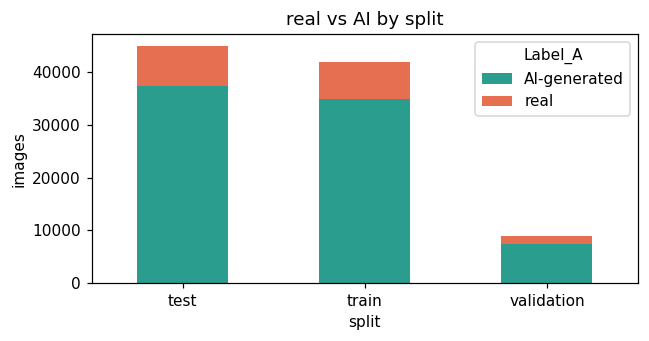

In [6]:
ct = pd.crosstab(meta["split"], meta["Label_A"].map(LABEL_A))
display(ct)
ct.plot.bar(stacked=True, color=["#2a9d8f", "#e76f51"], figsize=(6, 3.2))
plt.title("real vs AI by split"); plt.ylabel("images"); plt.xticks(rotation=0); plt.tight_layout()

**Finding — the binary task is imbalanced (~5:1 fake:real)** because every caption yields 1 real + 5 fakes, while Task B (generator attribution) is perfectly balanced.

*Handling plan:* class weights (weight `real` ~5x) or a balanced subsample **stratified by `Label_B`** so all five generators stay represented. Evaluate with **balanced-accuracy / macro-F1 / PR-AUC / per-class recall**, not raw accuracy.

## 3 · Image properties & shortcut audit
The danger in real-vs-AI datasets is that the model learns a **shortcut** (something correlated with the label but not the actual "AI-ness"). We audit the two classic ones — **aspect ratio** and **file format/compression** — on a small image sample pulled via `iter_batches` (no full-shard download).

In [7]:
SAMPLE_SHARD = by_split["validation"][0]
N_ROWS = 1024
t = time.time()
pf = pq.ParquetFile(fs.open(f"datasets/{REPO_ID}/{SAMPLE_SHARD}"))
batch = next(pf.iter_batches(batch_size=N_ROWS, columns=["Image", "Label_A", "Label_B", "Caption"]))
d = batch.to_pydict()
sample_bytes = [x["bytes"] for x in d["Image"]]
rows = []
for b, la, lb, cap in zip(sample_bytes, d["Label_A"], d["Label_B"], d["Caption"]):
    im = Image.open(io.BytesIO(b)); w, h = im.size
    rows.append(dict(Label_A=la, Label_B=lb, w=w, h=h, aspect=round(w/h, 3),
                     px=w*h, fmt=im.format, mode=im.mode, kb=round(len(b)/1024, 1), Caption=cap))
imgs = pd.DataFrame(rows)
imgs["cls"] = imgs["Label_A"].map(LABEL_A)
imgs["_i"] = range(len(imgs))
print(f"decoded {len(imgs)} images from {SAMPLE_SHARD} in {time.time()-t:.0f}s")
print("class counts in sample:", imgs["cls"].value_counts().to_dict())
imgs.groupby("cls")[["w", "h", "aspect", "px", "kb"]].describe().round(2).T

decoded 1024 images from data/validation-00000-of-00002.parquet in 10s
class counts in sample: {'AI-generated': 851, 'real': 173}


cls           AI-generated       real
w      count        851.00     173.00
       mean         698.52     575.95
       std          304.42      91.93
       min          270.00     324.00
       25%          436.00     500.00
       50%          768.00     640.00
       75%         1024.00     640.00
       max         1024.00     640.00
h      count        851.00     173.00
       mean         698.52     475.10
       std          304.42      91.17
       min          270.00     190.00
       25%          436.00     426.00
       50%          768.00     480.00
       75%         1024.00     500.00
       max         1024.00     640.00
aspect count        851.00     173.00
       mean           1.00       1.27
       std            0.00       0.34
       min            1.00       0.65
       25%            1.00       1.00
       50%            1.00       1.33
       75%            1.00       1.50
       max            1.00       2.40
px     count        851.00     173.00
       mean      580493.23  270246.70
       std       409383.35   49525.66
       min        72900.00   86450.00
       25%       190096.00  271360.00
       50%       589824.00  273280.00
       75%      1048576.00  307200.00
       max      1048576.00  409600.00
kb     count        851.00     173.00
       mean          77.44      49.12
       std           62.89      19.64
       min            8.80      10.50
       25%           22.55      36.30
       50%           68.30      46.60
       75%          116.80      61.10
       max          413.30     121.70

square-image rate by class: {'AI-generated': 1.0, 'real': 0.04}
format by class: {('AI-generated', 'JPEG'): 851, ('real', 'JPEG'): 173}


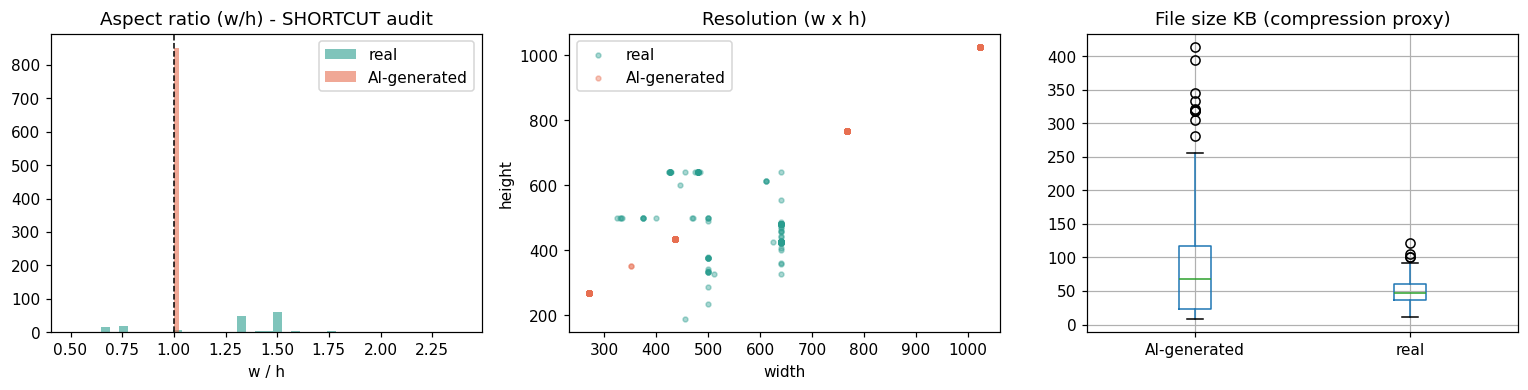

In [8]:
fig, ax = plt.subplots(1, 3, figsize=(14, 3.8))
for cls, c in [("real", "#2a9d8f"), ("AI-generated", "#e76f51")]:
    sub = imgs[imgs.cls == cls]
    ax[0].hist(sub.aspect, bins=40, alpha=0.6, label=cls, color=c)
    ax[1].scatter(sub.w, sub.h, s=10, alpha=0.4, label=cls, color=c)
ax[0].axvline(1.0, ls="--", c="k", lw=1); ax[0].set_title("Aspect ratio (w/h) - SHORTCUT audit")
ax[0].set_xlabel("w / h"); ax[0].legend()
ax[1].set_title("Resolution (w x h)"); ax[1].set_xlabel("width"); ax[1].set_ylabel("height"); ax[1].legend()
imgs.boxplot(column="kb", by="cls", ax=ax[2]); ax[2].set_title("File size KB (compression proxy)")
ax[2].set_xlabel(""); plt.suptitle(""); plt.tight_layout()

sq = imgs.assign(square=(imgs.aspect.sub(1).abs() < 0.02)).groupby("cls").square.mean().round(3)
print("square-image rate by class:", sq.to_dict())
print("format by class:", {k: v for k, v in imgs.groupby("cls").fmt.value_counts().items()})

**Findings**
- **Aspect ratio is a leak:** reals are photographic (varied w/h from MS COCO); fakes are overwhelmingly **square** (512², 768², 1024²). A model could cheat on shape alone.
- **Format is *not* a leak here:** both classes are stored as **JPEG** — but check the file-size/compression distribution; the paper applied JPEG-q50 perturbations to synthetic images, so *compression level* may still differ.

*Mitigation (bake into preprocessing):* **center-crop to square + resize to a fixed size** (e.g. 224²) and **re-encode all images to identical format/quality** before training, so neither shape nor compression can leak the label.

## 4 · Captions & content-bias control
Defactify pairs each real image with fakes generated **from the same caption**, so a detector can't win on *content*. Let's confirm the pairing and look at caption length.

No complete sextet in this sample window; showing one image per Label_B instead.


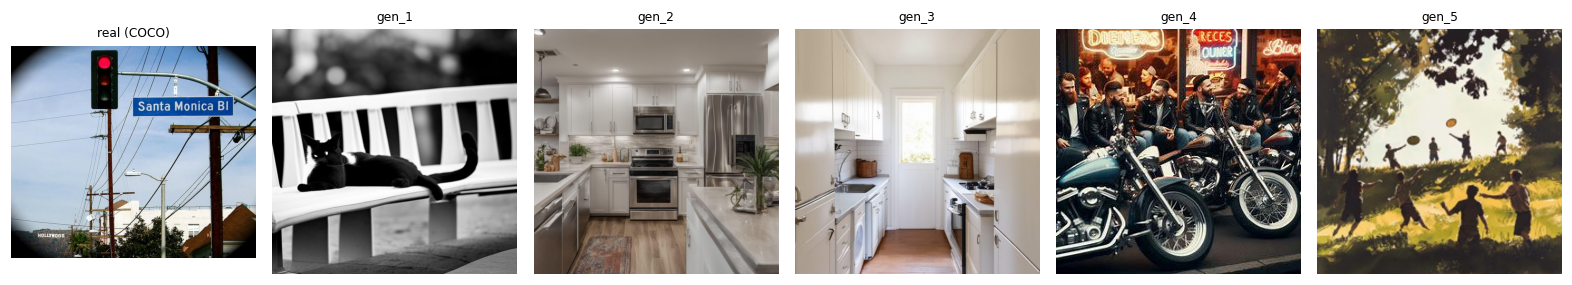

In [9]:
grp = imgs.groupby("Caption")["Label_B"].apply(set)
complete = [c for c, s in grp.items() if s >= {0, 1, 2, 3, 4, 5}]
if complete:
    cap = complete[0]
    sel = imgs[imgs.Caption == cap].sort_values("Label_B")
    fig, axes = plt.subplots(1, 6, figsize=(15, 3))
    for ax, (_, r) in zip(axes, sel.iterrows()):
        ax.imshow(Image.open(io.BytesIO(sample_bytes[r._i]))); ax.axis("off")
        ax.set_title("REAL" if r.Label_B == 0 else f"gen_{int(r.Label_B)}", fontsize=9)
    plt.suptitle(f"Same caption -> real + 5 generators:\n{cap[:90]}", fontsize=9); plt.tight_layout()
    print("Content-bias control confirmed: identical caption across real and all generators.")
else:
    print("No complete sextet in this sample window; showing one image per Label_B instead.")
    sel = imgs.sort_values("Label_B").groupby("Label_B").head(1)
    fig, axes = plt.subplots(1, len(sel), figsize=(2.4 * len(sel), 3))
    for ax, (_, r) in zip(np.atleast_1d(axes), sel.iterrows()):
        ax.imshow(Image.open(io.BytesIO(sample_bytes[r._i]))); ax.axis("off")
        ax.set_title(GEN[int(r.Label_B)], fontsize=8)
    plt.tight_layout()

caption length (words): mean 10.37, median 10, max 34


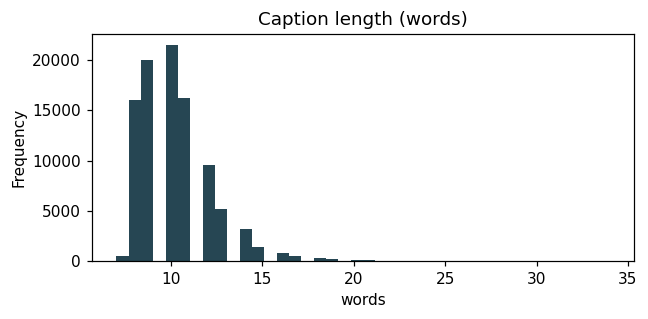

In [10]:
meta["cap_words"] = meta.Caption.str.split().str.len()
print("caption length (words): mean %.2f, median %d, max %d" % (
    meta.cap_words.mean(), meta.cap_words.median(), meta.cap_words.max()))
meta.cap_words.plot.hist(bins=40, figsize=(6, 3), color="#264653")
plt.title("Caption length (words)"); plt.xlabel("words"); plt.tight_layout()

## 5 · Leakage sanity check
For a valid evaluation, the same caption (hence its real/fake siblings) must **not** appear in more than one split.

In [11]:
cap_sets = {sp: set(meta.loc[meta.split == sp, "Caption"]) for sp in meta.split.unique()}
sp = list(cap_sets)
for i in range(len(sp)):
    for j in range(i + 1, len(sp)):
        inter = len(cap_sets[sp[i]] & cap_sets[sp[j]])
        flag = "  <-- LEAK" if inter else "  ok"
        print(f"{sp[i]:>10} n {sp[j]:<10}: {inter:>6} shared captions{flag}")
uniq = meta.Caption.nunique()
print(f"\nunique captions: {uniq:,} across {len(meta):,} rows  (~{len(meta)/uniq:.1f} images/caption)")

      test n train     :     31 shared captions  <-- LEAK
      test n validation:      7 shared captions  <-- LEAK
     train n validation:     25 shared captions  <-- LEAK

unique captions: 9,884 across 96,000 rows  (~9.7 images/caption)


## 6 · Summary & implications

**Confirmed facts**
- 96k images: **16k real (MS COCO) + 80k fake** (5 generators x 16k). Splits train/val/test.
- Labels: `Label_A` 0=real / 1=AI (binary); `Label_B` 0=real / 1-5=generator (balanced).
- Images: variable resolution (270²-1024²), reals photographic aspect ratios, fakes square, **all JPEG**.
- Captions shared between real and fakes (**content bias controlled** by design).

**Implications for the project**
1. **Imbalance (5:1):** class weights or `Label_B`-stratified balanced subsample; report balanced metrics.
2. **Shortcuts:** normalise **shape** (center-crop -> 224²) and **compression** (uniform re-encode) or the model cheats.
3. **Modelling:** transfer learning (pretrained CNN / CLIP head) — fast on the M4 Air.
4. **Drift (M6):** hold out one generator (leave-one-`Label_B`-out) to test generalisation to an unseen model.
5. **Leakage:** if captions overlap across splits (see §5), re-split by caption before training.

> Feeds directly into the M1 **dataset card**. ⚠️ Confirm the `Label_B` integer -> generator-name mapping against the dataset card.